# Retrieval-Augmented Generation (RAG) – Concept Introduction  
*(WHY part – Foundation before RAG)*

---

## 📌 Learning Flow

To understand **RAG (Retrieval-Augmented Generation)** clearly, we will follow a **WHY → WHAT → HOW** structure:

1. **WHY** do we need RAG?
2. **WHAT** exactly is RAG?
3. **HOW** do RAG-based systems work internally?

This section focuses completely on the **WHY part**, explained step-by-step using intuition and real-world analogies.

---

## 🤖 Understanding Large Language Models (LLMs)

Since the introduction of **LLMs**, the AI field has seen a massive revolution.  
But technically speaking, **what is an LLM?**

- LLMs are **large transformer-based neural network architectures**
- They contain **millions to billions of parameters**
- These parameters are nothing but **weights and biases**

---

## 🧠 Parametric Knowledge in LLMs

### 🔹 Pre-training Phase

- LLMs are **pre-trained on massive amounts of data**
- The scale of data is comparable to **a large portion of the internet**
- During this process, the model learns:
  - Language patterns
  - Facts
  - Reasoning structures
  - General world knowledge

### 🔹 Where is this knowledge stored?

All this learned knowledge is stored inside the **model parameters**  
→ in the form of numerical values (weights & biases)

This is called **Parametric Knowledge**

📌 **Key Insight**  
> The larger the number of parameters, the more knowledge the model can store.

Example:
- 7B parameters < 13B parameters < 70B parameters

---

## 🧑‍💻 How Users Access LLM Knowledge

Users interact with LLMs using **prompts**.

### Prompting Flow:
1. User sends a prompt
2. Model understands the intent
3. Model searches within its **parametric knowledge**
4. Generates the response **token by token**

This works well **most of the time**, but **not always**.

---

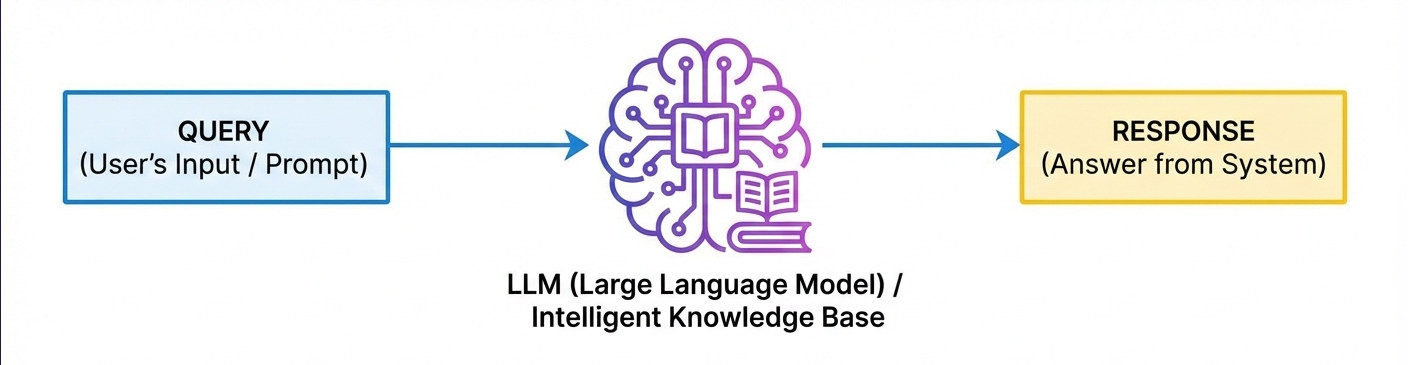
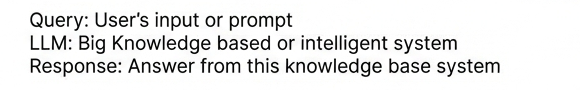

## ❌ Where Prompting Alone Fails

There are **three major scenarios** where accessing only parametric knowledge is not sufficient.

---

## 🚫 Scenario 1: Private / Internal Data

### Example:
- You have a private learning platform
- Videos and course content are **not public**
- You ask an LLM:
  > “What was explained at this timestamp in this video?”

❌ The LLM cannot answer.

### Why?
- The model **never saw your private data during pre-training**
- Hence, it has **zero knowledge** about it

📌 **Conclusion**  
> Prompting alone cannot help with private data.

---

## 🚫 Scenario 2: Recent or Real-Time Data

### Example:
- Asking:
  > “What is the biggest news in India today?”

❌ Most open-source LLMs will fail.

### Why?
- Every LLM has a **knowledge cutoff date**
- The model does **not know anything beyond that date**

📌 Important Note:
- Some tools (like ChatGPT) can answer because they have **internet access**
- Pure LLMs (downloaded from Hugging Face, etc.) cannot

---

## 🚫 Scenario 3: Hallucinations

### What is Hallucination?

- LLM generates **factually incorrect information**
- But presents it with **high confidence**

### Example:
> “Einstein played football for Germany in his early years.”

❌ Completely false  
But the model may still generate it confidently.

### Why does this happen?
- LLMs are **probabilistic**
- They predict the most likely next word, not the truth

📌 **Result**  
> User receives incorrect but convincing answers.

---

## ❓ Core Question

Can we solve these three problems?

1. Private data access  
2. Recent data access  
3. Hallucination reduction  

### ✅ Answer: YES (to some extent)

One traditional solution is **Fine-Tuning**

---

## 🛠️ What is Fine-Tuning?

Fine-tuning means:

- Taking a **pre-trained LLM**
- Training it **again**
- On a **smaller, domain-specific dataset**

📌 Goal:
> Inject domain-specific knowledge into the model

---

## 🏥 Example: Medical Domain

- Base LLM has general knowledge
- You collect medical Q&A data
- Fine-tune the model on this dataset
- Result:
  - Model answers medical questions better

---

## 🎓 Real-World Analogy

### Student Analogy:

- Engineering degree → **Pre-training**
- Company onboarding (2–3 months) → **Fine-tuning**

Even after general education, **job-specific training** is required.

---

## 🔧 Types of Fine-Tuning

### 1️⃣ Supervised Fine-Tuning (SFT)

- Uses **labeled data**
- Format:
  - Prompt → Desired Output
- Dataset size:
  - Thousands to lakhs of examples

📌 Model learns:
> “If the user asks this, respond like this”

---

### 2️⃣ Continued Pre-Training

- **Unsupervised**
- No labels
- Same objective as pre-training
- Uses domain-specific text

Example:
- Feeding lecture transcripts into the model

---

### 3️⃣ Other Techniques (Brief Mention)

- RLHF (Reinforcement Learning with Human Feedback)
- LoRA / QLoRA (parameter-efficient fine-tuning)

---

## 🔁 Supervised Fine-Tuning Process (4 Steps)

### Step 1: Data Collection
- Domain-specific
- Prompt–Answer pairs

### Step 2: Method Selection
- Full fine-tuning
- LoRA / QLoRA

### Step 3: Training
- Few epochs
- Computationally expensive

### Step 4: Evaluation
- Exact match
- Factual correctness
- Hallucination rate
- Safety tests

---

## ✅ How Fine-Tuning Solves the 3 Problems

### ✔ Private Data
- Data becomes part of parametric knowledge

### ✔ Recent Data
- Possible, but requires **repeated re-training**

### ✔ Hallucinations
- Can train model to say:
  > “I don’t know”  
- Reduces hallucination probability

---

## ❌ Limitations of Fine-Tuning

### 1️⃣ Computational Cost
- Training large models is expensive

### 2️⃣ Technical Expertise
- Requires skilled ML engineers

### 3️⃣ Frequent Updates Problem
- Any data change → retraining required
- Removing outdated info is also difficult

📌 **Conclusion**  
> Fine-tuning is not suitable for fast-changing data environments.

---

## 🔄 Back to the Question Again

Is there another technique that:
- Handles private data
- Handles recent data
- Reduces hallucinations
- Without retraining the model repeatedly?

### ✅ YES

That technique is called:

## **In-Context Learning**

➡️ This becomes the **foundation for RAG**, which we will explore next.

# In-Context Learning → Retrieval-Augmented Generation (RAG)  
*(WHY & WHAT complete, transitioning to HOW)*

---

## 🧠 What is In-Context Learning?

Let us first clearly understand **what this technique is**, and then we will discuss **how it helps solve the three major problems** we talked about earlier.

### 📖 Formal Definition

> **In-Context Learning** is a core capability of large language models such as **GPT-3, Claude, and LLaMA**, where the model learns to solve a task **purely by observing examples provided inside the prompt**, **without updating its weights**.

---

## 🔍 Key Difference from Traditional Learning

So far, we learned that:

- All knowledge in an LLM is stored inside its **parameters**
- This is called **parametric knowledge**
- When we send a prompt, the model:
  - Accesses this parametric knowledge
  - Generates an answer

However, in **large-scale models**, something interesting was observed:

> If you explain *how to solve a task* **inside the prompt itself using examples**,  
> the model can **learn the task on the fly**, without training.

This phenomenon is called **In-Context Learning**.

---

## ✨ Example: Sentiment Analysis using In-Context Learning

You send the following prompt:

- You first explain the task:
  - *Below are examples of text labeled with their sentiment*
- Then you provide examples:
  - “I love this phone. It’s so smooth.” → **Positive**
  - “This app crashes a lot.” → **Negative**
  - “The camera is amazing.” → **Positive**
- Then you give a **new sentence**:
  - “I hate the battery life.”

### 🧠 What does the model do?

- It observes the **pattern from examples**
- Learns how sentiment classification works
- Applies that learning to the new sentence
- Outputs:
  - **Negative**

📌 No training  
📌 No fine-tuning  
📌 Only prompt-based learning

---

## 🧩 More Task Examples

The same technique works for:

### 🔹 Named Entity Recognition (NER)
- You show:
  - A sentence
  - Its extracted entities
- You repeat with a few examples
- Then ask the model to extract entities from a new sentence

### 🔹 Math Problems
- Show solved examples
- Ask a new question
- Model follows the same reasoning pattern

### 🔹 Domain-Specific Tasks
- Any structured task can be taught via examples

---

## 🏷️ Few-Shot Prompting

This style of prompting is called:

> **Few-Shot Prompting**

- “Few” = small number of examples
- The prompt itself contains the learning signal

📌 **Few-shot prompting = practical implementation of In-Context Learning**

---

## 🌱 In-Context Learning as an Emergent Property

Now comes a very important concept.

### ❓ What is an Emergent Property?

> An **emergent property** is a behavior that **suddenly appears** when a system reaches a certain **scale and complexity**, even though it was **never explicitly programmed**.

---

### 🔬 Why is In-Context Learning Emergent?

- Early language models (GPT-1, GPT-2) were **too small**
- They **could not reliably learn from prompt examples**
- But when models became **very large**, this ability appeared naturally

### 🚀 GPT-3 Changed Everything

- GPT-3 had ~**175 billion parameters**
- Researchers observed:
  - It could learn tasks from prompt examples alone
- This behavior was **not planned**
- It emerged due to:
  - Large model size
  - Massive training data

---

## 📄 Landmark Paper: *Language Models are Few-Shot Learners*

This discovery was formalized in a famous paper:

### 📌 Key Ideas from the Paper

- Traditional NLP flow:
  - Pre-train a model
  - Fine-tune it for each task
- Problem:
  - Fine-tuning requires **10k–1M labeled examples**
  - Data creation is expensive

### 👤 Human Comparison

Humans can:
- Learn new tasks
- From only a **few examples**
- With minimal instructions

The paper asked:
> Can large language models do the same?

### ✅ Answer:
Yes — **at sufficient scale**

---

## 🔧 Improvements after GPT-3

Although In-Context Learning emerged naturally, it was **not perfect**.

So researchers improved it using:
- Supervised Fine-Tuning (SFT)
- RLHF (Reinforcement Learning with Human Feedback)
- Alignment techniques

This made:
- GPT-3.5
- GPT-4
- Claude

**much better at in-context learning**

---

## ⚠️ Limitations of In-Context Learning

Even though it is powerful:

- It does **not work equally well for all tasks**
- Performance depends on:
  - Prompt quality
  - Context clarity
  - Model capability

Still, it is a **foundational idea** behind RAG.

---

## 🔄 From Few-Shot Examples to Full Context

Now comes the **key transition**.

### ❓ What if instead of giving examples…

We provide:
- **All the required information**
- Directly inside the prompt

---

## 🎥 Real-World Example: Lecture-Based Chatbot

### Scenario:
- Website with long lecture videos (2–3 hours)
- Students have doubts while watching
- You want a chatbot to answer questions

### Traditional Prompting ❌
- Model does not know lecture content

### Improved Approach ✅
At prompt time, send:
1. Student’s question
2. Relevant lecture transcript (e.g., minute 5–25 on Gradient Descent)

📌 This transcript becomes **context**

---

## 🧠 What Happens Inside the Model?

- The model now has:
  - Its own parametric knowledge
  - Plus **external injected context**
- It combines both
- Generates an accurate answer

---

## 📘 Definition of RAG

> **Retrieval-Augmented Generation (RAG)** is a technique that makes a language model smarter by **providing additional relevant information at the time of the query**.

In our example:
- Extra information = lecture transcript
- Retrieved dynamically
- Injected into the prompt

---

## 🔁 RAG Flow (High-Level)

1. User asks a question
2. Relevant context is retrieved
3. Prompt is constructed with:
   - Context
   - User query
4. Model generates an answer using:
   - Context + parametric knowledge

---

## ✍️ Prompt Design Principle (Conceptual)

- Model is instructed:
  - Answer only from provided context
  - Say “I don’t know” if context is insufficient

📌 This directly **reduces hallucinations**

---

## 🔗 Connecting the Full Story

So far, we have:

1. Identified **three major problems**
   - Private data
   - Recent data
   - Hallucinations
2. Explored **fine-tuning**
   - Powerful but expensive
3. Introduced **in-context learning**
4. Enhanced it by injecting **retrieved context**
5. Arrived at **RAG**

---

## 🚀 What Comes Next?

- **WHY** → Covered  
- **WHAT** → Covered  

### 👉 Next Focus: **HOW**

We will now go deeper and understand:
- How RAG works internally
- Step-by-step system design
- How RAG practically solves all three problems

---

✨ *Hope the explanation so far feels intuitive and engaging.*


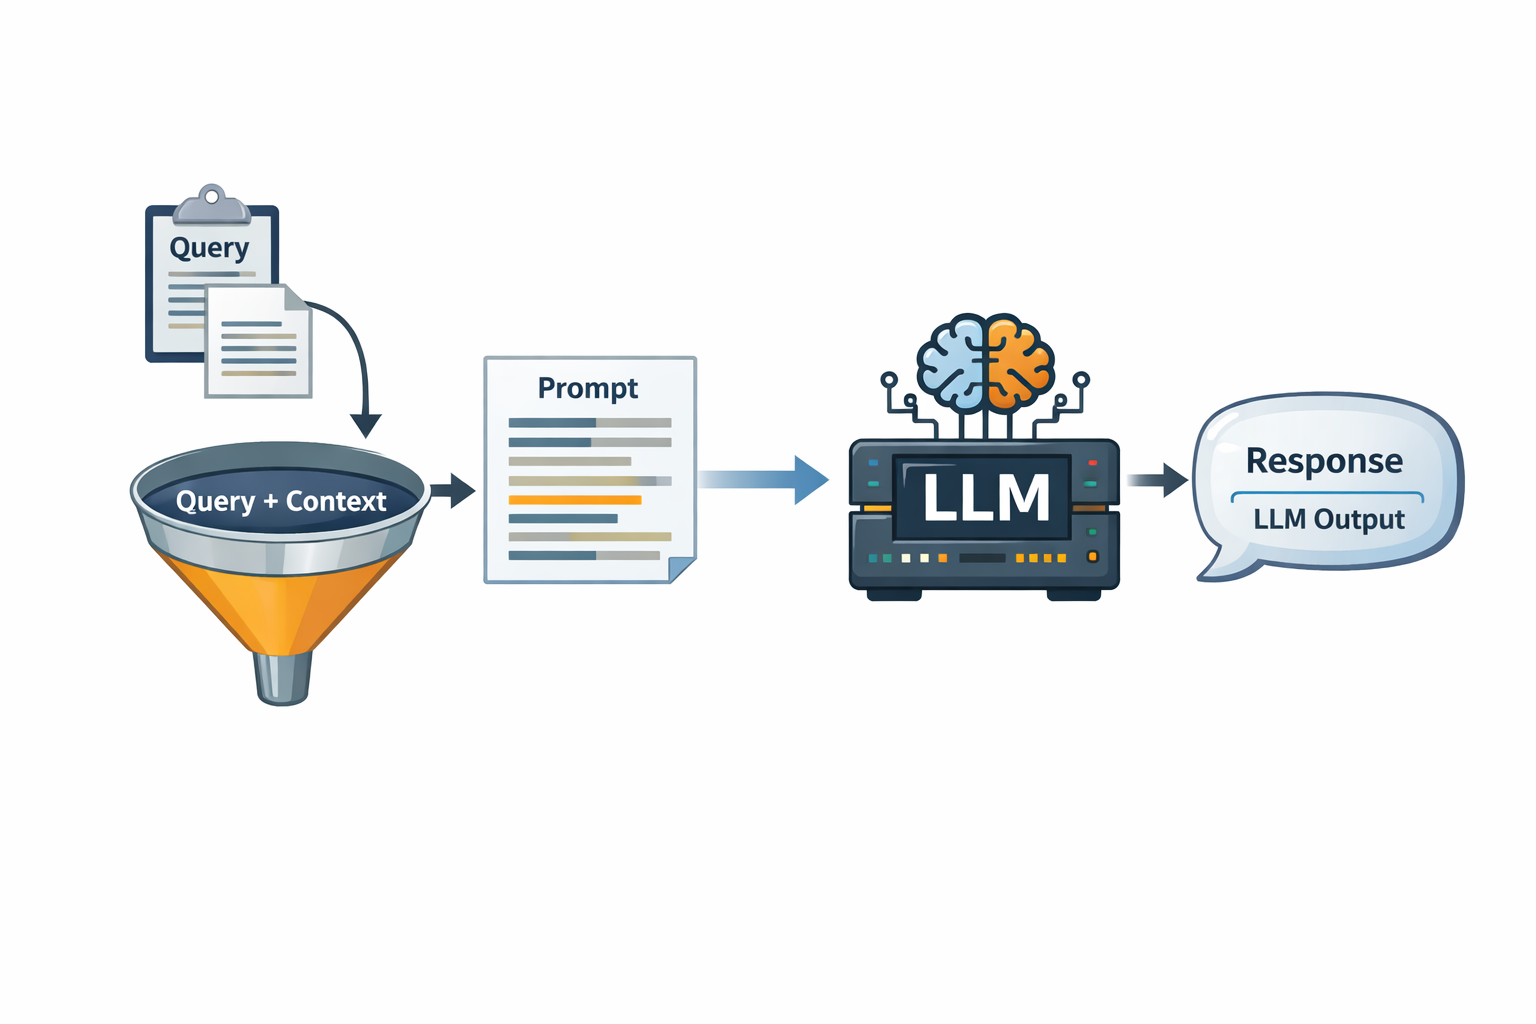

# Working of a RAG-Based System

Now let us move on to the next part.

The objective here is to understand **how a RAG-based system works in detail**. At a very high level, RAG is formed by combining **two fundamental concepts**:

- **Information Retrieval**, which is a long-established topic in the computer science domain  
- **Text Generation**, which gained widespread adoption after the emergence of Large Language Models (LLMs)

RAG is essentially the **combination (or marriage)** of these two ideas.

---

## High-Level Breakdown of RAG

Broadly speaking, a RAG-based system can be divided into **four major steps**:

1. **Indexing**
2. **Retrieval**
3. **Augmentation**
4. **Generation**

Before diving into detailed explanations using block diagrams, it is useful to first understand these four steps at a summarized, conceptual level.

---

## 1. Indexing

Indexing is the step where you **create an external knowledge base**.

This external knowledge base plays a critical role because the **context** that is eventually passed to the LLM inside the prompt comes from this source.

In simple terms:
- Any context required to answer a user query  
- Is derived from the **external knowledge base**

The complete process of **building and preparing this external knowledge base** is referred to as **Indexing**.

---

## 2. Retrieval

In the retrieval step, the system performs the following actions:

- It understands the user’s query  
- It searches the external knowledge base  
- It identifies the **most relevant chunks or sections**  
- That can help answer the query accurately  

### Example

Assume there is a **2-hour lecture on Linear Regression**.

Now, a user asks a question related specifically to **Gradient Descent**.

Clearly:
- Sending the entire 2-hour transcript to the LLM would be inefficient and unnecessary

Instead:
- The system searches within the transcript
- It identifies the segments where Gradient Descent is discussed

For example:
- One segment from minute **5 to 25**
- Another segment from minute **1:43 to 1:47**

These segments are the **relevant chunks**.

Rather than sending the full transcript, the system sends **only these selected parts as context**.

This entire process of locating and extracting relevant information from the knowledge base is called **Retrieval**.

---

## 3. Augmentation

Augmentation is the step where:

- The **user’s query**
- And the **retrieved context**
- Are combined together to form a **final prompt**

This stage is called augmentation because:
- You are effectively adding external knowledge
- On top of the LLM’s existing parameterized knowledge
- So that the model can produce a more accurate and grounded answer

---

## 4. Generation

In the final step:

- The constructed prompt is sent to the LLM  
- The LLM applies its **text generation capability**
- Along with **in-context learning**
- To generate a response to the query  

This is where the final answer is produced and returned to the user.

---

## Summary

At a high level, every RAG-based system follows these **four core steps**:

1. Indexing  
2. Retrieval  
3. Augmentation  
4. Generation  

With this foundational understanding in place, we can now move forward and **analyze each step in greater detail**.


# Indexing in a RAG-Based System

Let us start with **Indexing**, which is the **first step** of a RAG-based system.

Indexing can be defined as:

> **Indexing is the process of preparing your knowledge base so that it can be efficiently searched at query time.**

As discussed earlier, the **context** that we provide inside the prompt does not come from the LLM itself.  
Instead, this context is fetched from an **external knowledge base**.

The process of **creating and preparing this external knowledge base** is called **Indexing**.

---

## Overview of Indexing

Indexing itself is not a single step.  
It is composed of **multiple sub-steps**, which are performed one after another.

Broadly, indexing consists of the following stages:

1. Document Ingestion  
2. Text Chunking  
3. Embedding Generation  
4. Storing in a Vector Store  

Let us understand each of these steps in detail.

---

## 1. Document Ingestion

Document ingestion is the step where you **load your source knowledge into memory**.

Your data already exists somewhere:
- On a server
- In cloud storage
- In file systems or databases  

To use it in a RAG system, the **first requirement** is to fetch this data and load it into memory.

### Example

Consider the running example of a website where long lecture videos are hosted.

- The video transcript already exists on the server
- The first step is to **fetch this transcript from the server**
- And load it into memory

Similarly, if you are building a RAG-based system for:
- Company documents stored on **Google Drive**
- Or documents stored in **AWS S3**

Then fetching those documents from their respective sources becomes the first step.

This entire process of:
- Fetching documents from the source
- And loading them into memory  

Is called **Document Ingestion**.

### Tools Used

To perform document ingestion, tools like **LangChain** are commonly used.

LangChain provides many built-in **document loaders**, such as:
- PDF loaders
- YouTube loaders
- Web-based loaders  

The core idea of document ingestion is simple:
- Wherever your source knowledge exists
- Load it into memory
- So that further processing can be performed on it

After this step:
- Your document is available in memory
- Typically stored in the form of a **string**

---

## 2. Text Chunking

Once the document is ingested, the next step is **Text Chunking**.

In this step:
- A very large document
- Is broken down into **smaller documents or chunks**

### Why is Chunking Required?

There are two major reasons for doing this:

#### 1. LLM Context Length Limitation

LLMs have a limit on:
- How many tokens they can process at once  

Because of this limitation:
- You cannot send a very large document directly inside a prompt

#### 2. Semantic Search Quality

Later in the pipeline, we perform **semantic search**.

Semantic search does not work well when applied to:
- Very large documents as a whole

Instead:
- Semantic search performs better on **smaller, meaningful chunks**

Because of these two reasons, large documents are split into **smaller, semantically meaningful chunks**.

### Example

Consider again the **2-hour lecture video transcript**.

- A 2-hour transcript is extremely large
- Instead of treating it as one document
- It is divided into multiple chunks

Each chunk should be:
- Meaningful
- Focused on a specific topic

For example:
- One chunk discusses a single concept
- Another chunk discusses a different concept  

Chunks should not be created abruptly or randomly.

This topic was discussed in detail in the **Text Splitters** section earlier.

### Tools for Text Chunking

LangChain provides various **text splitters**, such as:
- Recursive Character Text Splitter (most commonly used)
- Semantic chunkers
- Document-type-specific splitters  

Depending on the data type:
- HTML-based splitters for HTML documents
- Markdown-based splitters for Markdown documents  

At this stage of indexing:
- The document has been ingested
- And divided into smaller, meaningful chunks

---

## 3. Embedding Generation

The third step in indexing is **Embedding Generation**.

Embeddings are a powerful deep learning technique used to:
- Capture the **semantic meaning** of unstructured data like text

In this step:
- Each text chunk
- Is converted into a **dense vector**
- That represents its semantic meaning

These dense vectors are called **Embeddings**.

### Why Are Embeddings Required?

In the future:
- Users will ask questions
- And we need to search which document chunks are most relevant

This search is not keyword-based.
It is **semantic search**.

Semantic search works by:
- Comparing vectors
- Measuring similarity between embedding vectors

That is why:
- All text chunks must be converted into embedding vectors

As described in the transcript:

> Convert each chunk into a dense vector that captures its meaning.

### Embedding Models

To generate embeddings, any embedding model can be used, such as:
- OpenAI Embeddings
- Sentence Transformer embeddings
- Or other popular embedding models

After this step:
- Every chunk has a corresponding dense embedding vector

---

## 4. Storing in a Vector Store

The fourth and final step of indexing is **storing embeddings in a vector store**.

Since we will perform semantic search in the future:
- We need a system that can efficiently store
- And search embedding vectors

### What Is Stored?

In the vector store, we save:
- The original text chunk
- Its corresponding embedding vector
- Along with any metadata

### Vector Store Options

There are multiple vector store options available:

**Local vector stores:**
- FAISS
- Chroma  

**Cloud-based vector stores:**
- Pinecone
- Weaviate
- Milvus
- Qdrant  

Once stored:
- All chunks and their embeddings exist together in a vector database

---

## Final Outcome of Indexing

After completing all four steps:

1. Document Ingestion  
2. Text Chunking  
3. Embedding Generation  
4. Vector Storage  

We achieve the final goal of indexing:

- A fully prepared **external knowledge base**
- Stored inside a vector store
- Ready for semantic search

This vector store now acts as the **external knowledge base** for the RAG system.

In the future:
- We will search this knowledge base
- Retrieve relevant chunks
- And inject them as context into the prompt

With this, the **first step of RAG (Indexing)** is complete, and the external knowledge base is successfully set up.


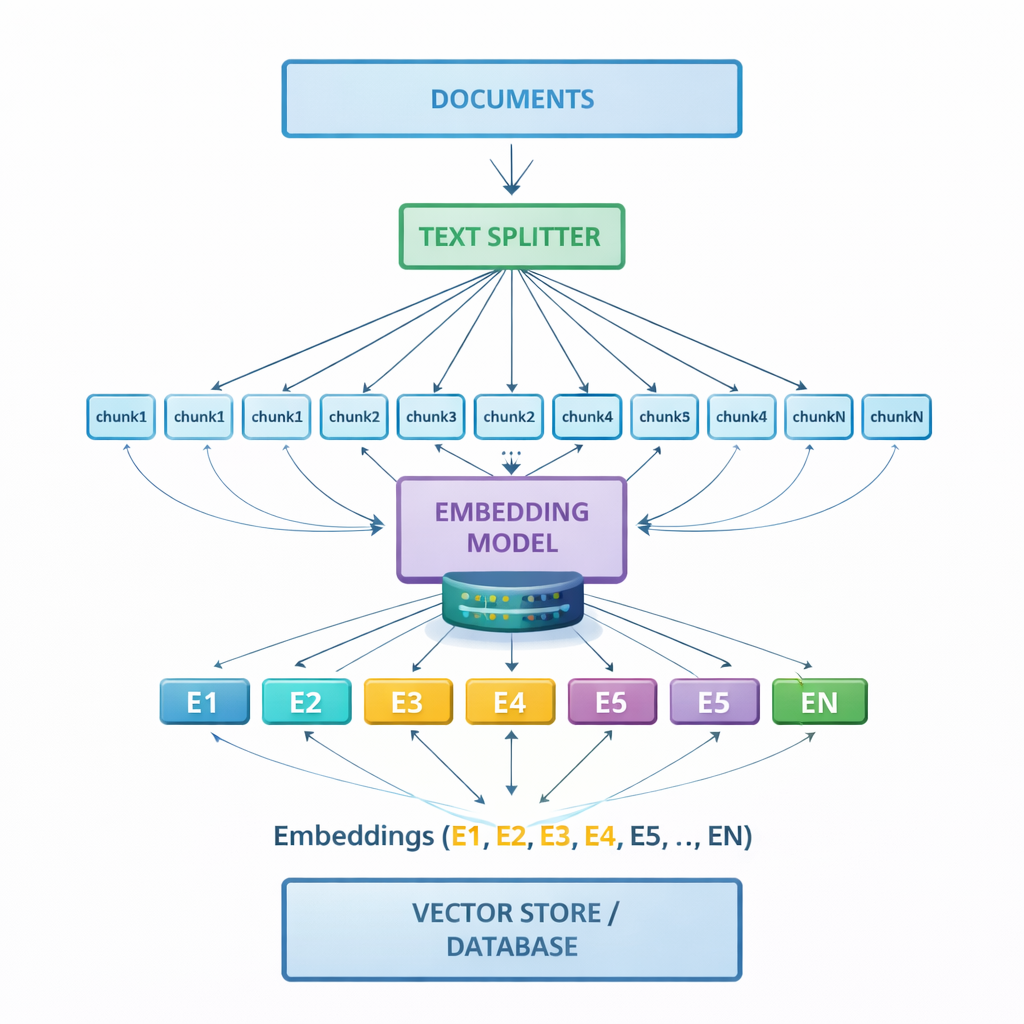

# Retrieval in a RAG-Based System

At this point, the **user sends a query** to the system.

For example, the user asks:

> **“How do we perform the optimization step in Gradient Descent?”**

As soon as the query arrives, the **second step of RAG is triggered**, which is **Retrieval**.

---

## Goal of the Retrieval Step

The main goal of retrieval is:

- To understand the user’s query
- And decide **which document chunks**
- From the existing vector store
- Are the **best candidates to be used as context**

In other words, based on the query, we want to figure out:
> **Which vectors should be selected to form the final context?**

---

## Intuition with an Example

Assume the external knowledge base contains chunks related to:

- Ordinary Least Squares (OLS)
- Multiple Linear Regression
- Gradient Descent (first section)
- Gradient Descent (another section)

Now, since the user’s question is **specifically about Gradient Descent**:

- Chunks related to OLS will not be used
- Chunks related to Multiple Linear Regression will not be used
- Only the chunks discussing **Gradient Descent** will be selected

Instead of picking just one chunk:
- Multiple relevant Gradient Descent chunks can be **combined**
- And together they form the **context**

This exact decision-making happens during the **Retrieval step**.

---

## Definition of Retrieval

> **Retrieval is the real-time process of finding the most relevant pieces of information from a pre-built index (vector store) based on the user’s question.**

You can think of it as asking:

> “From all the knowledge I have, which 3 to 5 chunks will best help answer this query?”

---

## Role of the Retriever Component

To perform retrieval, the system uses a **Retriever component**.

The retriever is responsible for executing multiple internal steps to find the most relevant chunks.

---

## Internal Steps of Retrieval

### Step 1: Query Embedding Generation

- The user query is first converted into an **embedding vector**
- The **same embedding model** is used:
  - That was used earlier to create embeddings for document chunks
- This ensures:
  - Query and document embeddings lie in the **same vector space**
  - And have the **same dimensionality**

At this stage:
- The query is now represented as a dense vector

---

### Step 2: Semantic Search in the Vector Store

Next, the retriever searches the vector store to find:

- Which document vectors are **closest to the query vector**

This is where **semantic search** happens.

Depending on the system design:
- Simple similarity-based search can be used
- Or more advanced techniques can be applied

Examples mentioned earlier include:
- Basic semantic similarity search
- MMR (Maximum Marginal Relevance)
- Contextual compression techniques

Regardless of the technique:
- The objective remains the same
- Find vectors that are **semantically closest** to the query

---

### Step 3: Ranking the Retrieved Results

Once candidate vectors are found:

- They are **ranked**
- Based on how close they are to the query vector

Ranking can be done using:
- Simple similarity metrics like cosine similarity
- Or more advanced reranking algorithms

After ranking:
- Results are ordered from **most relevant to least relevant**

---

### Step 4: Fetching the Final Context

From the ranked list:

- The **top results** are selected
- Their corresponding **text chunks** are fetched
- These chunks together form the **final context**

This context is exactly what will be:
- Injected into the prompt
- And sent to the LLM in the next stage

---

## State After Retrieval

At this point:

- The **Indexing step** is already complete  
- The **Retrieval step** is now complete  

This means we now have:
- The **user query**
- And the **relevant contextual information**

Both are ready to be used in the next step of RAG.

The next stages will focus on:
- Combining query and context (Augmentation)
- And generating the final answer (Generation)


# Augmentation in a RAG-Based System

Now we move to the **next stage**, which is **Augmentation**.

At this stage, our objective is to **create a prompt** that contains:
- The **user’s query**
- And the **retrieved context**

This prompt will then be sent to the LLM.

---

## What Happens Before Augmentation?

By the time we reach this stage:

- The **Retriever** has already done its job
- We already have the **most relevant chunks**
- These chunks together are called the **context**

So now we have two things ready:
1. User query  
2. Relevant context (retrieved from the vector store)

---

## Goal of the Augmentation Step

The goal of augmentation is:

- To **combine the query and the context**
- Into a **single, well-structured prompt**
- That guides the LLM to answer correctly

This is why the step is called **Augmentation**:
- We are **augmenting** the LLM’s internal (parameterized) knowledge
- With **external knowledge** provided at query time

---

## Prompt Construction (Conceptual View)

Using the block diagram perspective:

- The query is taken **as it is**
- The retrieved context is injected along with it
- Both are merged into a single prompt

Conceptually, the prompt looks like this:

- A **system instruction** defining behavior  
- The **provided context**  
- The **user’s question**

The instruction clearly tells the model:
- Answer **only from the provided context**
- If the context is insufficient, say **“I don’t know”**

This instruction is important to:
- Prevent hallucinations
- Keep answers grounded in retrieved data

---

## Why Augmentation Is a Critical Step

This step is critical because:

- The LLM does **not automatically know**
  - Which information is trustworthy
- Augmentation explicitly tells the model:
  - What information to use
  - What information to ignore

Without proper augmentation:
- Even a good retriever can fail
- The model may mix external context with unrelated parametric knowledge

---

## Output of the Augmentation Stage

After augmentation:

- We have a **final prompt**
- That contains:
  - User query
  - Relevant context
  - Clear behavioral instructions

This marks the **completion of Step 3** in RAG.

---

## State of the RAG Pipeline So Far

At this point:

- ✅ Indexing is complete  
- ✅ Retrieval is complete  
- ✅ Augmentation is complete  

Which means:
- Query + Context are now ready
- To be sent to the LLM for the **final step**

The **next step** will be:
- **Generation**, where the LLM produces the final answer using this augmented prompt


# Generation: Final Step of the RAG Pipeline

Now comes the **final part of the entire RAG pipeline**, which is **Generation**.

In the generation stage:
- You take an **LLM**
- And send the **final prompt** to it

This final prompt already contains:
- The **user query**
- The **retrieved context**

The LLM reads the prompt, understands the context, and then **generates the correct response**.

---

## Flow of the Generation Step

According to the flow diagram:

1. A prompt is created using:
   - User query
   - Retrieved context
2. This prompt is sent to the **LLM**
3. The LLM:
   - Uses its **parametric knowledge**
   - Along with the **additional external knowledge (context)**
4. Finally, it generates a response

This is how the **RAG pipeline completes** its execution.

---

## How the Complete RAG Pipeline Works

So overall, this is how a RAG-based system works:

- Query and context are combined into a prompt
- The prompt is passed to the LLM
- The LLM generates an answer grounded in context

Using the diagram shown on the screen, the RAG architecture should now be clear:
- **Visually**
- And **conceptually**

This setup is a **basic RAG architecture**.

By improving this same architecture, you can build:
- More **advanced**
- More **robust**
- More **production-ready** RAG-based systems  
These improvements will be discussed later.

At this point, you should have a **good understanding of RAG architecture**.

---

## Revisiting the Three Core Problems

Now let us go back to the **three problems** discussed earlier and understand how RAG solves them **one by one**.

---

## Problem 1: LLMs Cannot Answer Using Private Data

LLMs by default cannot answer questions on **private or internal data**.

RAG solves this problem very clearly because:

- You create an **external knowledge base**
- This knowledge base is built using **your own data**
- The context is derived from this data only

As a result:
- The retrieved context comes from your data
- The LLM’s answers are also based on your data

So the first problem is **directly and effectively solved** by RAG.

---

## Problem 2: Knowledge Cutoff of LLMs

Every LLM has a **knowledge cutoff date**.

If you ask about:
- Recent events
- Current news
- Latest developments  

The LLM may not know the answer.

RAG solves this problem by allowing you to:
- Add **recent articles**
- Add **latest news**
- Add **current affairs data**

All you need to do is:
- Add this new information to the **external knowledge base**

Once done:
- The retriever can fetch this information
- The LLM can answer questions related to recent data

### Comparison with Fine-Tuning

In fine-tuning:
- Every time new information arrives
- You need to **retrain or fine-tune the model**
- Which is **costly and time-consuming**

In RAG:
- You simply add new documents
- Generate embeddings
- Store them in the vector database
- **No retraining is required**

This makes RAG **much less costly** and more flexible.

---

## Problem 3: Hallucinations

Hallucination is another major issue in LLMs.

RAG reduces hallucinations because:

- You provide **exact context** related to the query
- You explicitly instruct the LLM:
  - Answer only from the provided context
  - If information is insufficient, say **“I don’t know”**

This means:
- The LLM’s response is **grounded**
- Answers are tied directly to retrieved content

As a result:
- The chances of hallucination are **significantly reduced**

---

## Why RAG Is Better Than Fine-Tuning

Compared to fine-tuning, RAG is:

- **Cheaper**
- **Simpler**
- **Less complex**

Reasons:
- No model training required
- No labeled dataset required
- No expensive retraining cycles

You simply:
- Take your company documents
- Convert them into embeddings
- Store them in a vector store

In contrast:
- Fine-tuning requires full training workflows
- Proper datasets
- Higher cost and complexity

So in many real-world scenarios, **RAG is a cheaper and simpler alternative to fine-tuning**.

---

## Final Takeaway

RAG-based systems:
- Solve private data access
- Handle recent information
- Reduce hallucinations
- Avoid costly retraining

This makes RAG a **practical, scalable, and production-friendly architecture** for building LLM-powered applications.
